# 4x3 Grid World: Value and Policy Iteration

In this example, we will use Gymnasium, an environment to train agents via reinforcement learning (RL). We will not use RL here but just use the environment with a custom simple reflex-based agent. Classic Rl environments are implemented in `gym_classics`.

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../Intro/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [51]:
import numpy as np
np.set_printoptions(precision=2)

In [52]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

from gym_classics.utils import print_gridworld
from gym_classics.gridworld_utils import gridworld_to_matrix, gridworld_image, \
                                         gridworld_image_list, gridworld_animation

## Define the $4 \times 3$ Grid World

The used example is the simple $4 \times 3$ grid world described in AIMA Chapter 17.

![4x3 grid world description](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/AIMA_Figure_17_1.png)

AIMA Figure 17.1: (a) A simple, stochastic 
 environment that presents the agent with a sequential decision problem. (b) Illustration of the transition model of the environment: the “intended” outcome occurs with probability 0.8, but with probability 0.2 the agent moves at right angles to the intended direction. A collision with a wall results in no movement. Transitions into the two terminal states have reward +1 and -1, respectively, and all other transitions have a reward of -0.04.


`gym_classic` defines an abstract gridworld class. Here we extend the `NoisyGridWorld` which implements the non-determnistic 80/10/10 navigation actions for 
the example.

In [53]:
from gym_classics.envs.abstract.noisy_gridworld import NoisyGridworld

class OriginalClassicGridworld(NoisyGridworld):
    layout = """
|   G|
| X G|
|S   |
"""

    def __init__(self):
        super().__init__(OriginalClassicGridworld.layout)

    def _reward(self, state, action, next_state):
        return {(3, 1): -1.0, (3, 2): 1.0}.get(state, -0.04)

    def _done(self, state, action, next_state):
        return state in self._goals  

gym.register('OriginalClassicGridworld-v0', entry_point=OriginalClassicGridworld)

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment OriginalClassicGridworld-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


### Model Access Functions

gym_classic extends the Gymnasium environment API with:

- `states(self)` - returns a generator over all feasible states
- `actions(self)` - returns a generator over all feasible actions
- `model(self, state, action)` - returns all transitions from the given state-action pair

**Note:** These are not standard Gymnasium methods!

We can use `make()` to create registered environments. Gymnasium uses wrappers, so we have unwrap the environment first to get the extended model API.

In [54]:
gym_env = gym.make('OriginalClassicGridworld-v0')
env = gym_env.unwrapped

Visualize the layout with state ids.

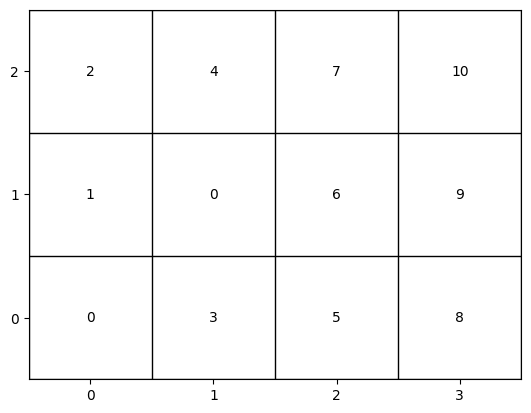

In [55]:
gridworld_image(env)

In [56]:
print("States:", env.states())
print("Actions:", env.actions())
print("Starts:", env._starts)
print("Goals:", env._goals)

States: range(0, 11)
Actions: range(0, 4)
Starts: ((0, 0),)
Goals: frozenset({(3, 1), (3, 2)})


In [57]:
print("Start state index for coordinates (0,0):", env.encode((0,0)))
print("Model for state 3 and action 1:\n(next_states, rewards, terminals, probs)\n", env.model(0,1))

Start state index for coordinates (0,0): 0
Model for state 3 and action 1:
(next_states, rewards, terminals, probs)
 (array([0, 1, 3]), array([-0.04, -0.04, -0.04]), array([0., 0., 0.]), array([0.1, 0.1, 0.8]))


Stack the arrays for better readability.

In [58]:
np.stack(env.model(0,1), axis=1 )

array([[ 0.  , -0.04,  0.  ,  0.1 ],
       [ 1.  , -0.04,  0.  ,  0.1 ],
       [ 3.  , -0.04,  0.  ,  0.8 ]])

## Value Iteration

The algorithm repeatedly sweeps over all states and updates the state value given the state values around it. The algorithm stops with the optimal value function when the state values do not change anymore. 

Finally, a optimal policy is extracted as the policy choosing actions greedily with respect to the value function (i.e., choose the best action in each state).  

![Algorithm: Value Iteration](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_VI.png)

The state value update for $V(s)$ can be broken into a 
1. Bellman backup that calculates the Q-value for a state action pair from the current value function. 
2. Choosing the largest Q-value as the new state value. This represents choosing the best action and therefore, getting the best Q-value as the state value.

In [59]:
def backup(env, discount, V, state, action):
    next_states, rewards, terminals, probs = env.model(state, action)
    bootstraps = (1.0 - terminals) * V[next_states]
    return np.sum(probs * (rewards + discount * bootstraps))

In [60]:
def value_iteration(env, discount, precision=1e-3):
    assert 0.0 <= discount <= 1.0
    assert precision > 0.0
    
    V = np.zeros(env.observation_space.n, dtype=np.float64)

    while True:
        V_old = V.copy()

        for s in env.states():
            Q_values = [backup(env, discount, V, s, a) for a in env.actions()]
            V[s] = max(Q_values)

        # this is delta 
        if np.max(np.abs(V - V_old)) <= precision:
            break
        
    return V

**Note:** Since numpy provides convenient vectorized operations, the whole value function is copied and $\delta$ is evaluated in the stopping condition over all states.

In [61]:
V_star = value_iteration(env, discount=1)
print(V_star, end='\n\n')

print_gridworld(env, V_star)    

[ 0.71  0.76  0.81  0.65  0.87  0.61  0.66  0.92  0.39 -1.    1.  ]

+0.81  +0.87  +0.92  +1.00  
+0.76         +0.66  -1.00  
+0.71  +0.65  +0.61  +0.39  


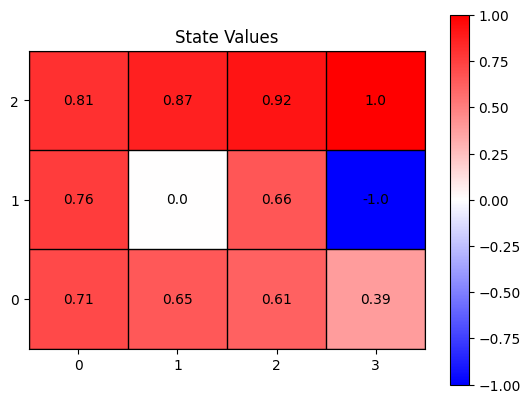

In [62]:
gridworld_image(env, V_star, labels=True, title='State Values')

Let's look at Q-values calculated using the Bellman backup for all actions in state 0 (bottom-left corner).

In [63]:
Q_values = [backup(env, discount=1, V=V_star, state=0, action=a) for a in env.actions()]
np.vstack((env.actions(), Q_values)).transpose()

array([[0.  , 0.71],
       [1.  , 0.63],
       [2.  , 0.66],
       [3.  , 0.67]])

The best action is up (`0`) which produced the state value.

### Extract the Optimal Policy

We can extract the optimal greedy policy from the value function. Greedy means to pick for each state the action with the largest Q-value, which is the best action. 

In [64]:
def greedy_policy(env, V, discount=1):
    policy = np.zeros(len(env.states()))

    for s in env.states():
        Q_values = [backup(env, discount, V, s, a) for a in env.actions()]
        policy[s] = np.argmax(Q_values)

    return policy

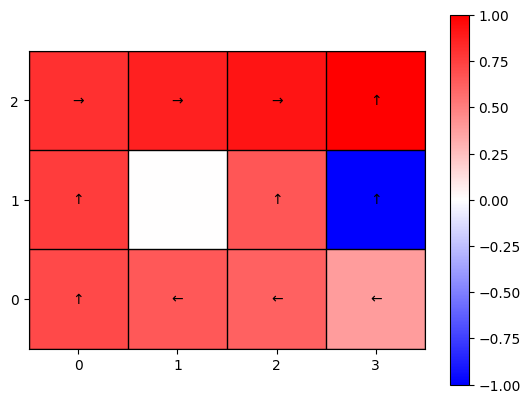

In [65]:
pol_start = greedy_policy(env, V_star)
gridworld_image(env, V_star, policy = pol_start)

### Algorithm Progress

In [66]:
from gym_classics.algorithms import value_iteration

Vs = value_iteration(env, discount=1, precision=0.1, history=True, verbose=True)
Vs

.........
Converged after 9 sweeps.


[array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([-0.04, -0.04, -0.04, -0.04, -0.04, -0.04, -0.04, -0.04, -0.04,
        -1.  ,  1.  ]),
 array([-0.08, -0.08, -0.08, -0.08, -0.08, -0.08, -0.08,  0.75, -0.08,
        -1.  ,  1.  ]),
 array([-0.12, -0.12, -0.12, -0.12,  0.54, -0.12,  0.45,  0.88, -0.13,
        -1.  ,  1.  ]),
 array([-0.16, -0.16,  0.36, -0.16,  0.77,  0.29,  0.61,  0.91,  0.08,
        -1.  ,  1.  ]),
 array([-0.2 ,  0.22,  0.64,  0.16,  0.84,  0.47,  0.65,  0.92,  0.24,
        -1.  ,  1.  ]),
 array([ 0.13,  0.51,  0.75,  0.37,  0.86,  0.54,  0.66,  0.92,  0.32,
        -1.  ,  1.  ]),
 array([ 0.42,  0.66,  0.79,  0.47,  0.87,  0.56,  0.66,  0.92,  0.34,
        -1.  ,  1.  ]),
 array([ 0.58,  0.72,  0.8 ,  0.51,  0.87,  0.57,  0.66,  0.92,  0.35,
        -1.  ,  1.  ]),
 array([ 0.65,  0.75,  0.81,  0.58,  0.87,  0.58,  0.66,  0.92,  0.36,
        -1.  ,  1.  ])]

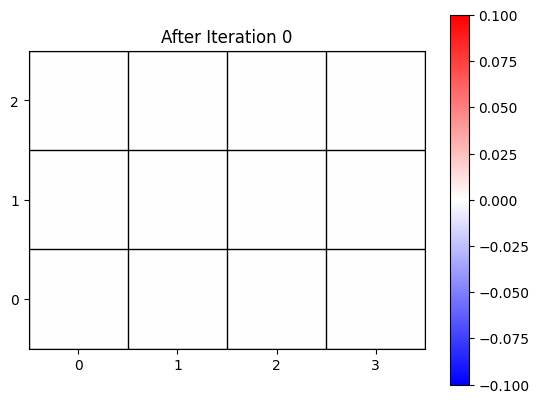

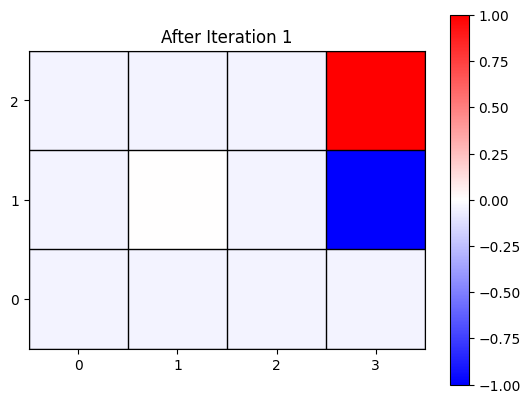

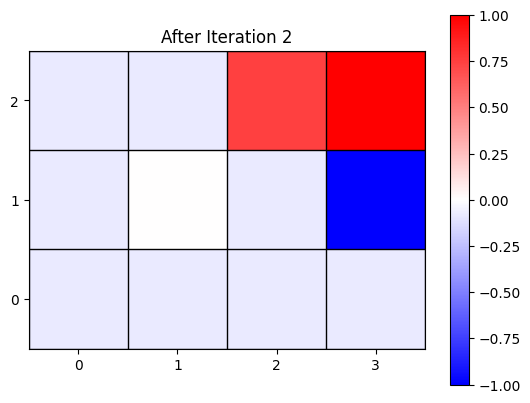

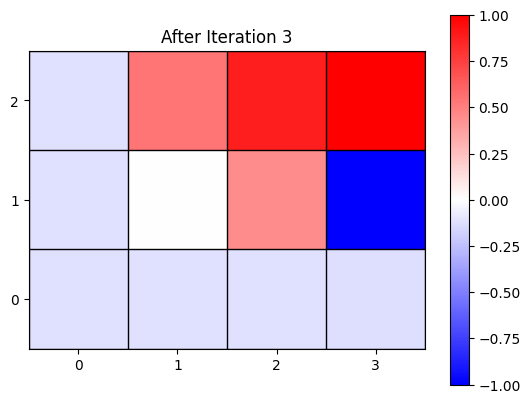

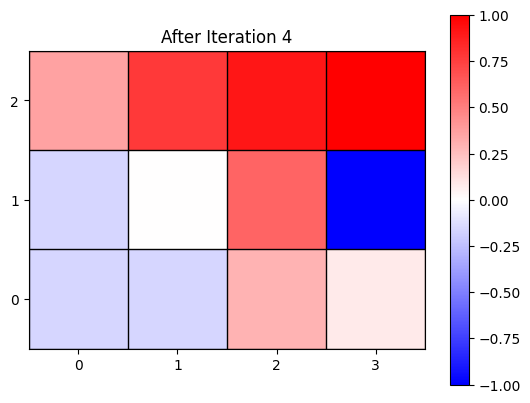

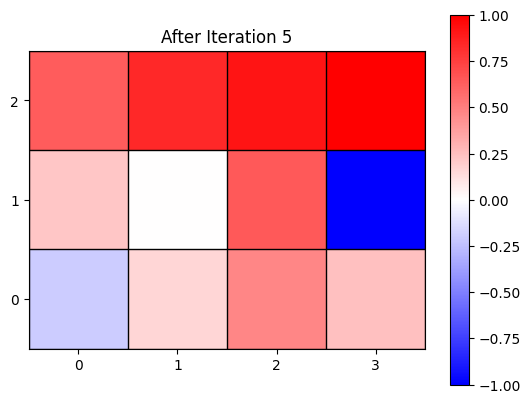

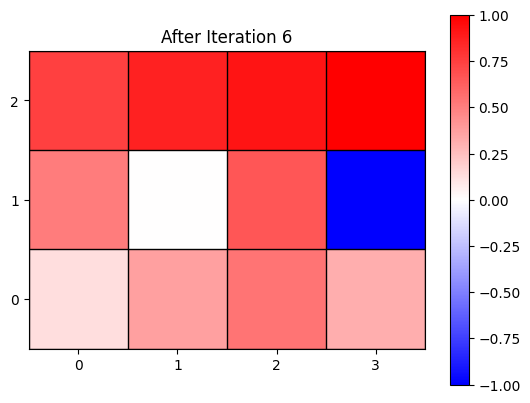

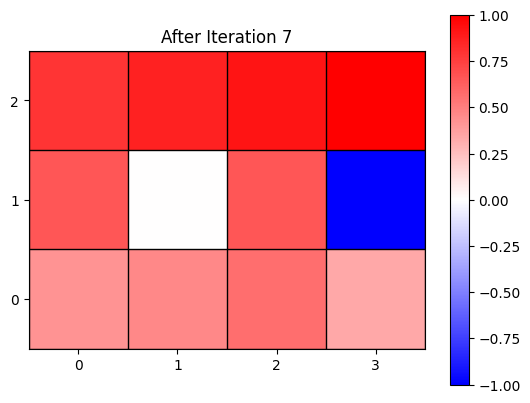

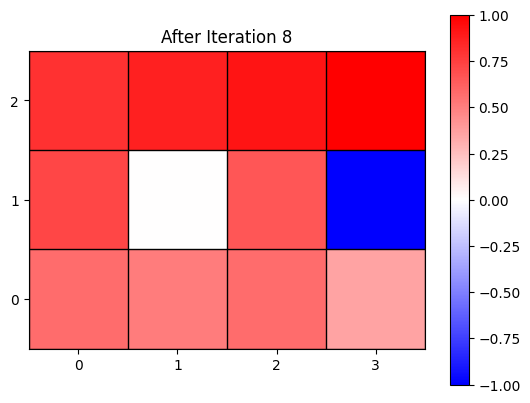

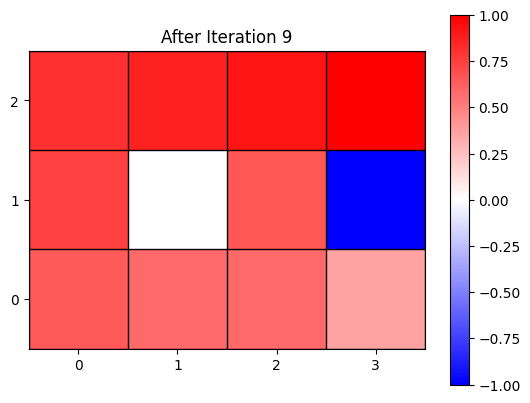

In [67]:

gridworld_image_list(env, Vs)

In [68]:
gridworld_animation(env, Vs)

## Policy Iteration



### The Policy

We represent a policy as an integer vector.

In [69]:
def random_policy(env):
    return np.random.choice(env.actions(), size=len(env.states()))

random_pol = random_policy(env)
random_pol

array([0, 1, 3, 0, 0, 0, 3, 0, 2, 2, 0])

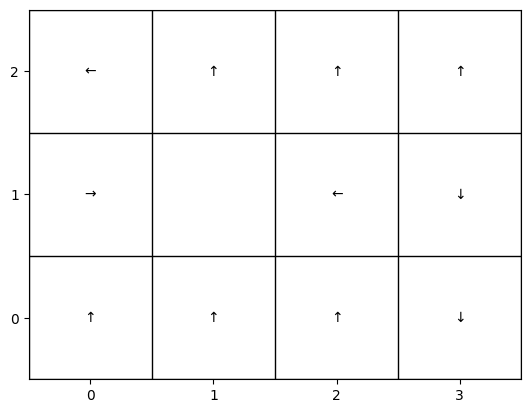

In [70]:
gridworld_image(env, policy = random_pol)

### The Policy Iteration Algorithm

The algorithm consists of iteratively evaluating the current policy (i.e., calculating the value function) and then improving the policy based on the 
value function (i.e., finding the greedy policy). The policy is guaranteed to improve in every step till it stabilizes as the optimal policy. 

![Algorithm: Policy Iteration](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_Alg_PI.png)

### Policy Evaluation

Policy evaluation calculates the value function for a policy. It looks like value iteration, but following a fixed policy.

In [71]:
def backup(env, discount, V, state, action):
    next_states, rewards, dones, probs = env.model(state, action)
    bootstraps = (1.0 - dones) * V[next_states]
    return np.sum(probs * (rewards + discount * bootstraps))

def policy_evaluation(env, discount, policy, precision=1e-3, max_iterations=1000):
    assert 0.0 <= discount <= 1.0
    assert precision > 0.0
    V = np.zeros(policy.shape, dtype=np.float64)

    while True:
        V_old = V.copy()

        for s in env.states():
            V[s] = backup(env, discount, V, s, policy[s])

        if np.abs(V - V_old).max() <= precision or max_iterations <= 0:
            break

        max_iterations -= 1
    return V

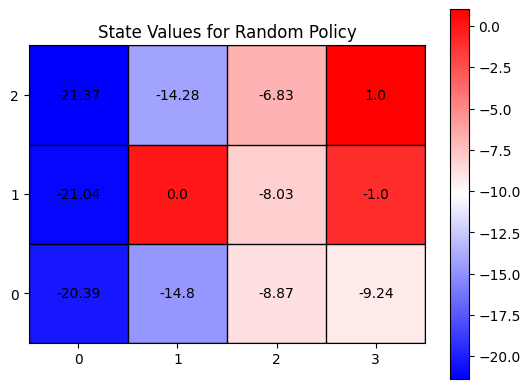

In [72]:
V_random = policy_evaluation(env, discount=1, policy=random_pol)
gridworld_image(env, V_random, labels=True, title='State Values for Random Policy')

### Policy Improvement

Policy improvement calculates a policy greedy with respect to the current policy's value function (i.e., always pick the action with the largest Q-value).

In [73]:
def policy_improvement(env, discount, policy, V_policy, precision=1e-3):
    policy_old = policy.copy()
    V_old = V_policy.copy()

    for s in env.states():
        Q_values = [backup(env, discount, V_policy, s, a) for a in env.actions()]
        policy[s] = np.argmax(Q_values)
        V_policy[s] = max(Q_values)

    stable = np.logical_or(
        policy == policy_old,
        np.abs(V_policy - V_old).max() <= precision,
    ).all()

    return policy, stable

[1 2 1 1 1 0 1 1 0 0 0]


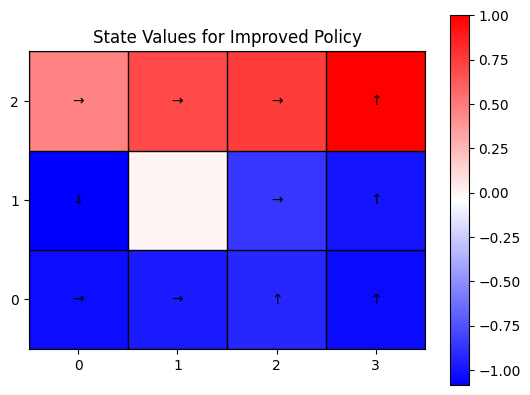

In [74]:
pol, stable = policy_improvement(env, discount=1, policy=random_pol, V_policy=V_random)
print(pol)

V_pol = policy_evaluation(env, discount=1, policy=pol)
gridworld_image(env, V_pol, policy=pol, title='State Values for Improved Policy')


### The Complete PI Algorithm

In [75]:
def policy_iteration(env, discount, precision=1e-3):
    assert 0.0 <= discount <= 1.0
    assert precision > 0.0

    policy = random_policy(env)

    while True:
        V_policy = policy_evaluation(env, discount, policy, precision)
        policy, stable = policy_improvement(env, discount, policy, V_policy, precision)
        if stable:
            break
        
    return policy


In [76]:
pol_star = policy_iteration(env, discount=1)
print(pol_star)

V_pol_star = policy_evaluation(env, discount=1, policy=pol_star)

[0 0 1 3 1 3 0 1 3 0 0]


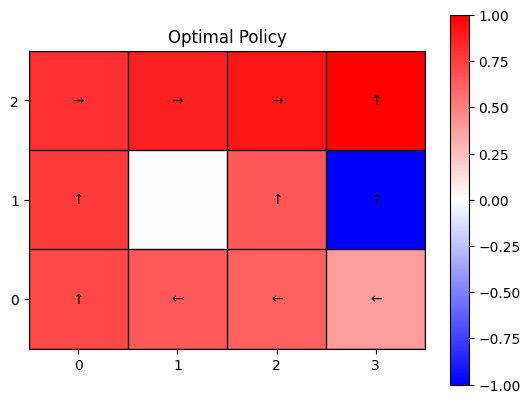

In [77]:
gridworld_image(env, V_pol_star, policy=pol_star, title='Optimal Policy')

### Visualize the Algorithm Progress

In [78]:
from gym_classics.algorithms import policy_iteration

policy_list, V_list = policy_iteration(env, discount=1, history=True, verbose=True)

display(policy_list)

......
Converged after 6 iterations.


[array([1, 3, 3, 0, 0, 0, 0, 1, 3, 0, 2]),
 array([1, 2, 2, 1, 1, 0, 0, 1, 3, 0, 0]),
 array([1, 2, 1, 1, 1, 0, 0, 1, 3, 0, 0]),
 array([1, 0, 1, 1, 1, 0, 0, 1, 3, 0, 0]),
 array([0, 0, 1, 3, 1, 0, 0, 1, 3, 0, 0]),
 array([0, 0, 1, 3, 1, 3, 0, 1, 3, 0, 0])]

In [80]:
gridworld_animation(env, V_list, policies=policy_list)


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)